## Introduction

The objective of this analysis is to apply statistical concepts to the cleaned Titanic datasets. The analysis covers descriptive statistics, probability distributions, hypothesis testing, and correlation analysis to understand patterns within the datasets and support data-driven decision-making.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid")

In [76]:
titanic = pd.read_csv("Titanic_Cleaned.csv")

In [77]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [78]:
titanic.var(numeric_only=True)

PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Age              169.512498
SibSp              1.216043
Parch              0.649728
Fare            2469.436846
dtype: float64

In [79]:
titanic.std(numeric_only=True)

PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             13.019697
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64

In [80]:
titanic.median(numeric_only=True)

PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

In [81]:
titanic.mode().iloc[0]

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           28.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Embarked                         S
Name: 0, dtype: object

In [82]:
# Statistical Summary:
# Fare has the largest variability, indicating substantial differences in ticket prices.
# Age is centred around the late twenties.
# Most passengers travelled in Third Class and did not survive.

In [83]:
#Probability Distributions

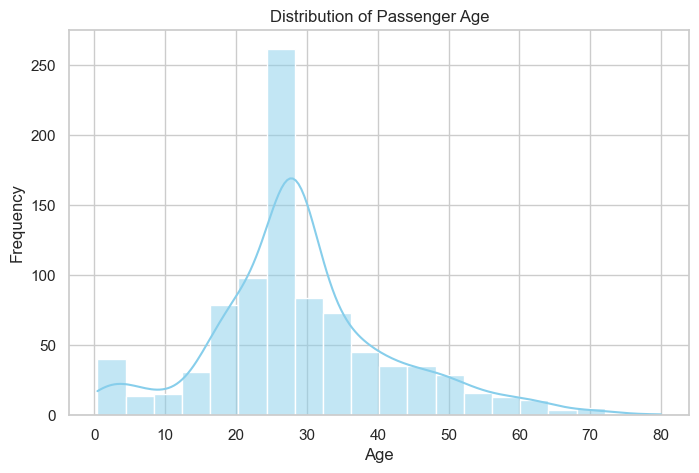

In [84]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic,
    x="Age",
    bins=20,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

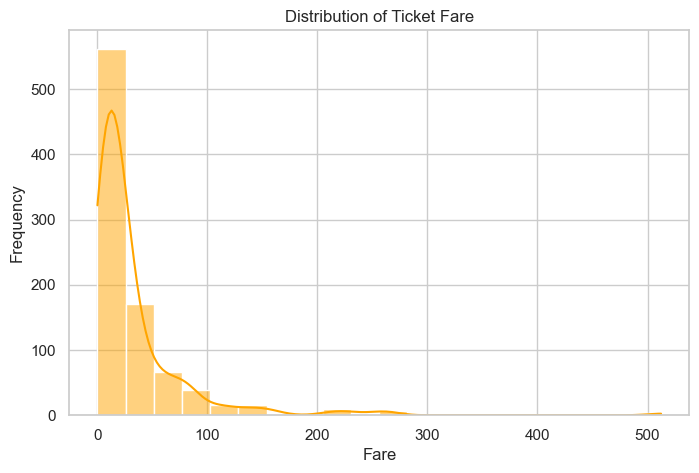

In [85]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic,
    x="Fare",
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Distribution of Ticket Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.savefig("Titanic_Fare_distribution.png", dpi=300)
plt.show()

In [86]:
print("Age Skewness:", titanic["Age"].skew())
print("Fare Skewness:", titanic["Fare"].skew())

Age Skewness: 0.5102446555756495
Fare Skewness: 4.787316519674893


In [87]:
# Probability Distribution Summary:
# - Age is moderately positively skewed (skewness = 0.510), indicating that most passengers were younger, with fewer older passengers.
# - Fare is highly positively skewed (skewness = 4.787), showing that while most passengers paid relatively low fares, a few paid exceptionally high fares.
# - The Fare distribution contains significant outliers and is not normally distributed.

In [88]:
#Hypothesis Test

In [89]:
#Research Question
#Is there a significant difference in the average age of passengers who survived and those who did not?

In [90]:
# Hypothesis

# H0: There is no significant difference in the average age of survivors and non-survivors.

# H1: There is a significant difference in the average age of survivors and non-survivors.

In [91]:
# Age of survivors
survivors = titanic[titanic["Survived"] == 1]["Age"]

# Age of non-survivors
non_survivors = titanic[titanic["Survived"] == 0]["Age"]

In [92]:
t_stat, p_value = ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.8966053920256696
P-value: 0.058309159977757444


In [93]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in the average age of survivors and non-survivors.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average age of survivors and non-survivors.")

Fail to reject the null hypothesis.
There is no statistically significant difference in the average age of survivors and non-survivors.


In [94]:
# Hypothesis Test Summary:
# The p-value (0.0583) is greater than the significance level (0.05),
# so we fail to reject the null hypothesis.
# This indicates that there is no statistically significant difference
# in the average age of survivors and non-survivors.

In [95]:
##Correlation vs Causation

In [96]:
# Correlation matrix
titanic_corr = titanic.corr(numeric_only=True)

# Display the matrix
print(titanic_corr)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


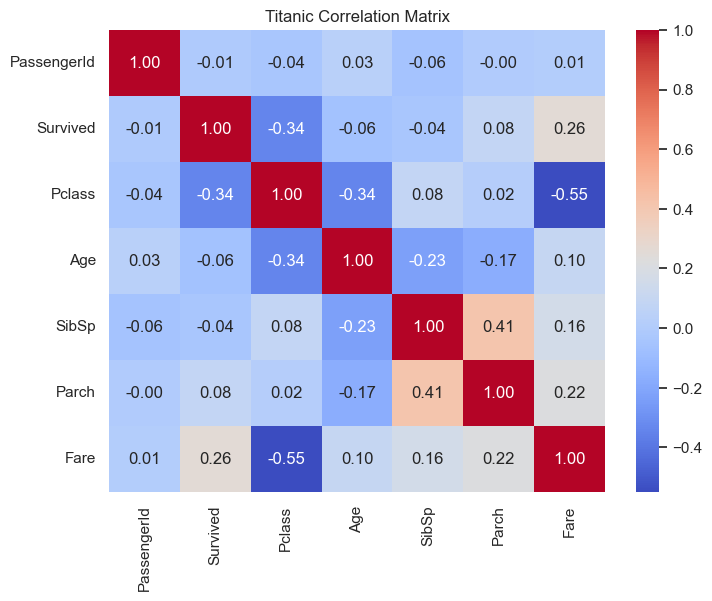

In [97]:
plt.figure(figsize=(8,6))

sns.heatmap(
    titanic_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Correlation Matrix")
plt.savefig("titanic_cmp.png", dpi=300)
plt.show()

In [98]:
# Correlation Summary:
# Passenger Class has the strongest relationship with survival (r = -0.34).
# Fare is positively correlated with survival (r = 0.26), suggesting that passengers who paid higher fares were more likely to survive.
# Age, SibSp, and Parch show weak correlations with survival.

In [99]:
# Feature Importance:
# Pclass and Fare appear to be the most useful predictors of survival.
#No pair of predictor variables shows a very high correlation (|r| > 0.8), suggesting that there are no strongly redundant features in either dataset.